In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
# Load the electricity dataset

file_path = "/Users/ms/Desktop/Internships/1M1B/Electric_Production.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

display(df.head())

Dataset loaded successfully.
Dataset shape: (397, 2)


,DATE,Value
0,01-01-1985,72.5052
1,02-01-1985,70.6720
2,03-01-1985,62.4502
3,04-01-1985,57.4714
4,05-01-1985,55.3151


In [3]:
# Basic information about the dataset

print("Column names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Column names:
['DATE', 'Value']

Data types:
DATE         str
Value    float64
dtype: object

Missing values:
DATE     0
Value    0
dtype: int64

Duplicate rows:
0


In [4]:
# Display statistical summary

print("Statistical summary of electricity values:")
display(df["Value"].describe())

Statistical summary of electricity values:


count    397.000000
mean      88.847218
std       15.387834
min       55.315100
25%       77.105200
50%       89.779500
75%      100.524400
max      129.404800
Name: Value, dtype: float64

In [5]:
# Convert the date column into datetime format
df["DATE"] = pd.to_datetime(df["DATE"])

# Make sure electricity values are numeric
df["Value"] = pd.to_numeric(df["Value"], errors="coerce")

# Remove rows with missing date or value
df = df.dropna(subset=["DATE", "Value"])

# Sort data chronologically
df = df.sort_values("DATE").reset_index(drop=True)

print("Data preprocessing completed.")

print("\nNumber of records:", len(df))
print("Starting date:", df["DATE"].min().date())
print("Ending date:", df["DATE"].max().date())

display(df.head())

Data preprocessing completed.

Number of records: 397
Starting date: 1985-01-01
Ending date: 2018-01-01


,DATE,Value
0,1985-01-01,72.5052
1,1985-02-01,70.6720
2,1985-03-01,62.4502
3,1985-04-01,57.4714
4,1985-05-01,55.3151


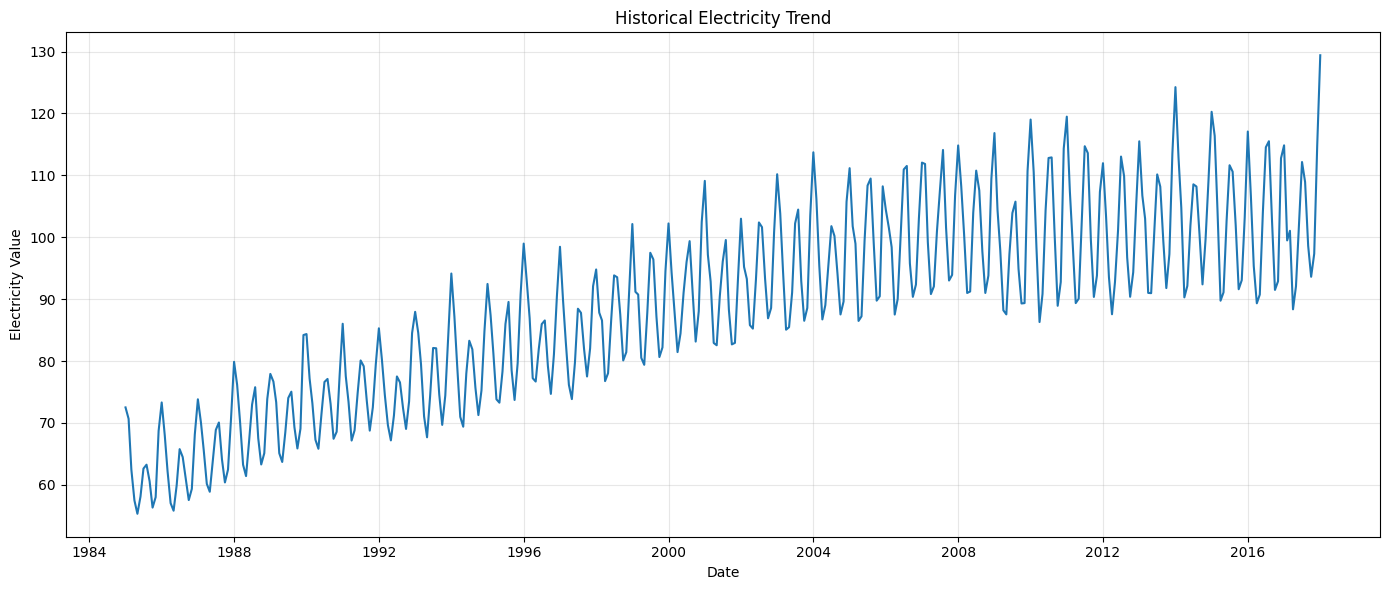

In [6]:
# Visualize historical electricity values

plt.figure(figsize=(14, 6))

plt.plot(
    df["DATE"],
    df["Value"],
    linewidth=1.5
)

plt.title("Historical Electricity Trend")
plt.xlabel("Date")
plt.ylabel("Electricity Value")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
# Calculate yearly average electricity value

df["Year"] = df["DATE"].dt.year

yearly_average = df.groupby("Year")["Value"].mean()

display(yearly_average.to_frame("Average Electricity Value"))

,Average Electricity Value
Year,
1985,62.165667
1986,62.709892
1987,65.740275
1988,69.716358
1989,71.895167
1990,73.313433
1991,75.111850
1992,75.120908
1993,77.678992


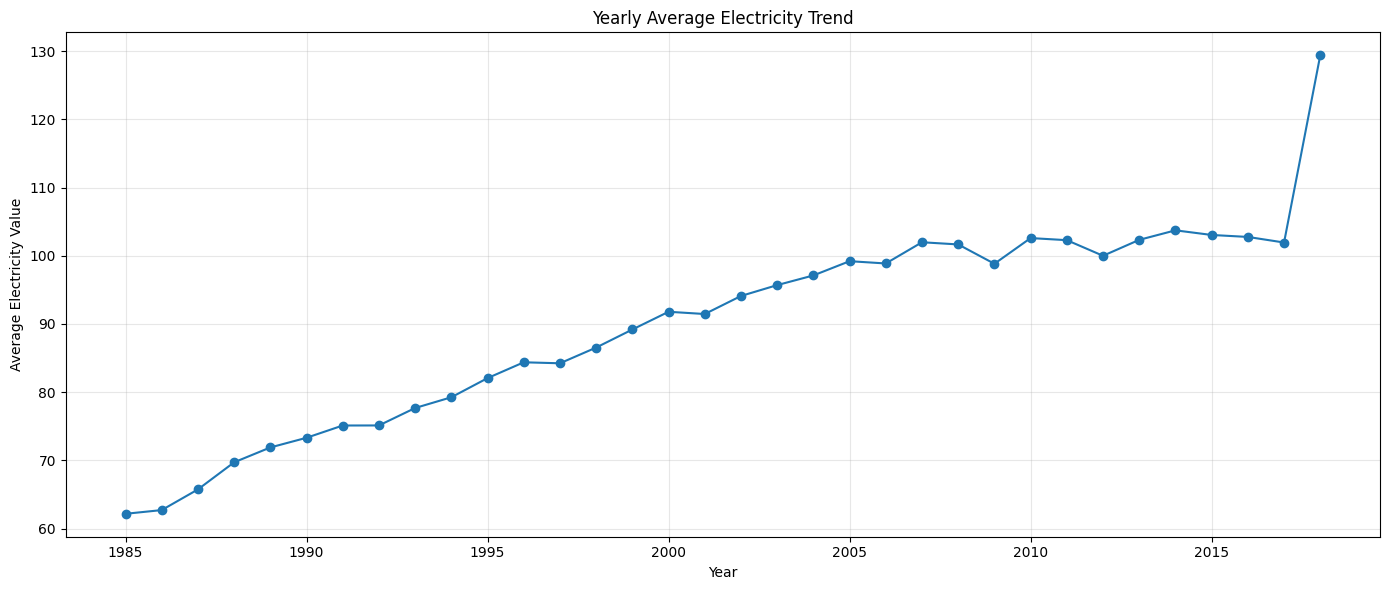

In [8]:
# Visualize yearly average electricity values

plt.figure(figsize=(14, 6))

plt.plot(
    yearly_average.index,
    yearly_average.values,
    marker="o",
    linewidth=1.5
)

plt.title("Yearly Average Electricity Trend")
plt.xlabel("Year")
plt.ylabel("Average Electricity Value")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
# Extract month from the date

df["Month"] = df["DATE"].dt.month

# Calculate average electricity value for each month
monthly_average = df.groupby("Month")["Value"].mean()

display(monthly_average.to_frame("Average Electricity Value"))

,Average Electricity Value
Month,
1,102.100241
2,94.095521
3,87.902691
4,79.134518
5,79.414367
6,87.415906
7,94.944915
8,95.169848
9,86.484391


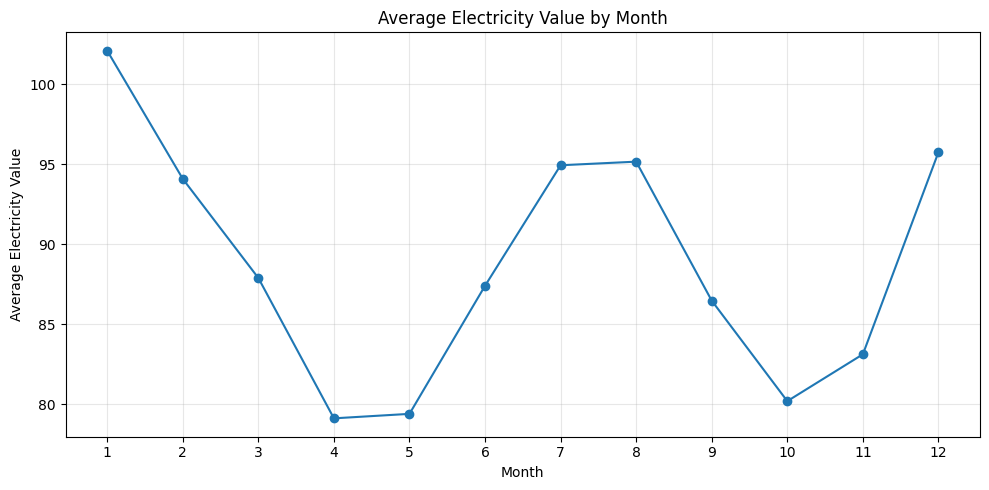

In [10]:
# Visualize average electricity value by month

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_average.index,
    monthly_average.values,
    marker="o",
    linewidth=1.5
)

plt.title("Average Electricity Value by Month")
plt.xlabel("Month")
plt.ylabel("Average Electricity Value")

plt.xticks(range(1, 13))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
# Create a separate dataframe for machine-learning forecasting

model_df = df[["DATE", "Value"]].copy()

model_df["Year"] = model_df["DATE"].dt.year
model_df["Month"] = model_df["DATE"].dt.month

# Previous electricity values
model_df["Lag_1"] = model_df["Value"].shift(1)
model_df["Lag_2"] = model_df["Value"].shift(2)
model_df["Lag_3"] = model_df["Value"].shift(3)
model_df["Lag_6"] = model_df["Value"].shift(6)
model_df["Lag_12"] = model_df["Value"].shift(12)

# Previous-period rolling averages
model_df["Rolling_Mean_3"] = (
    model_df["Value"].shift(1).rolling(3).mean()
)

model_df["Rolling_Mean_6"] = (
    model_df["Value"].shift(1).rolling(6).mean()
)

model_df["Rolling_Mean_12"] = (
    model_df["Value"].shift(1).rolling(12).mean()
)

# Remove rows where lag values are not available
model_df = model_df.dropna().reset_index(drop=True)

print("Forecasting dataset created.")
print("Number of usable records:", len(model_df))

display(model_df.head())

Forecasting dataset created.
Number of usable records: 385


,DATE,Value,Year,Month,Lag_1,Lag_2,Lag_3,Lag_6,Lag_12,Rolling_Mean_3,Rolling_Mean_6,Rolling_Mean_12
0,1986-01-01,73.3057,1986,1,68.7145,58.0005,56.3154,62.6202,72.5052,61.010133,61.580617,62.165667
1,1986-02-01,67.9869,1986,2,73.3057,68.7145,58.0005,63.2485,70.6720,66.673567,63.361533,62.232375
2,1986-03-01,62.2221,1986,3,67.9869,73.3057,68.7145,60.5846,62.4502,70.002367,64.151267,62.008617
3,1986-04-01,57.0329,1986,4,62.2221,67.9869,73.3057,56.3154,57.4714,67.838233,64.424183,61.989608
4,1986-05-01,55.8137,1986,5,57.0329,62.2221,67.9869,58.0005,55.3151,62.413967,64.543767,61.953067


In [12]:
# Features used by the machine-learning models

feature_columns = [
    "Year",
    "Month",
    "Lag_1",
    "Lag_2",
    "Lag_3",
    "Lag_6",
    "Lag_12",
    "Rolling_Mean_3",
    "Rolling_Mean_6",
    "Rolling_Mean_12"
]

X = model_df[feature_columns]
y = model_df["Value"]

print("Input features:")
print(feature_columns)

print("\nTarget variable:")
print("Value")

Input features:
['Year', 'Month', 'Lag_1', 'Lag_2', 'Lag_3', 'Lag_6', 'Lag_12', 'Rolling_Mean_3', 'Rolling_Mean_6', 'Rolling_Mean_12']

Target variable:
Value


In [13]:
# Split the data chronologically.
# The first 80% is used for training and the last 20% for testing.

split_index = int(len(model_df) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

dates_train = model_df["DATE"].iloc[:split_index]
dates_test = model_df["DATE"].iloc[split_index:]

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

print("\nTraining period:")
print(dates_train.min().date(), "to", dates_train.max().date())

print("\nTesting period:")
print(dates_test.min().date(), "to", dates_test.max().date())

Training records: 308
Testing records: 77

Training period:
1986-01-01 to 2011-08-01

Testing period:
2011-09-01 to 2018-01-01


In [14]:
# Random Forest forecasting model

rf_model = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    min_samples_leaf=2,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [15]:
# Gradient Boosting forecasting model

gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_predictions = gb_model.predict(X_test)

print("Gradient Boosting model trained successfully.")

Gradient Boosting model trained successfully.


In [16]:
# Function to calculate model performance

def evaluate_model(model_name, actual, predicted):

    mae = mean_absolute_error(actual, predicted)

    rmse = np.sqrt(
        mean_squared_error(actual, predicted)
    )

    r2 = r2_score(actual, predicted)

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    }


# Evaluate both models

results = []

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_predictions
    )
)

results.append(
    evaluate_model(
        "Gradient Boosting",
        y_test,
        gb_predictions
    )
)

results_df = pd.DataFrame(results)

display(results_df)

,Model,MAE,RMSE,R2 Score
0,Random Forest,2.981245,4.127173,0.813956
1,Gradient Boosting,3.226218,4.288972,0.799083


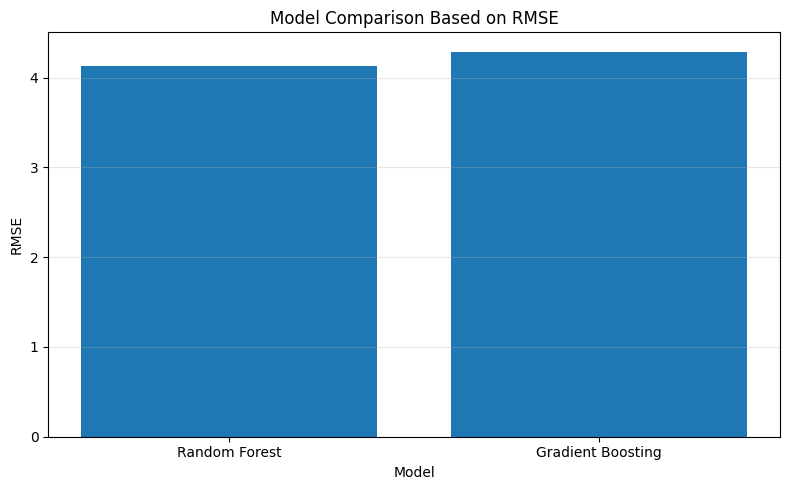

In [17]:
# Visual comparison of RMSE values

plt.figure(figsize=(8, 5))

plt.bar(
    results_df["Model"],
    results_df["RMSE"]
)

plt.title("Model Comparison Based on RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
# Select the model with the lowest RMSE

best_model_name = results_df.loc[
    results_df["RMSE"].idxmin(),
    "Model"
]

if best_model_name == "Random Forest":

    best_model = rf_model
    best_predictions = rf_predictions

else:

    best_model = gb_model
    best_predictions = gb_predictions


best_result = results_df[
    results_df["Model"] == best_model_name
].iloc[0]

print("Best model:", best_model_name)

print("\nBest model performance:")
print("MAE      :", round(best_result["MAE"], 4))
print("RMSE     :", round(best_result["RMSE"], 4))
print("R2 Score :", round(best_result["R2 Score"], 4))

Best model: Random Forest

Best model performance:
MAE      : 2.9812
RMSE     : 4.1272
R2 Score : 0.814


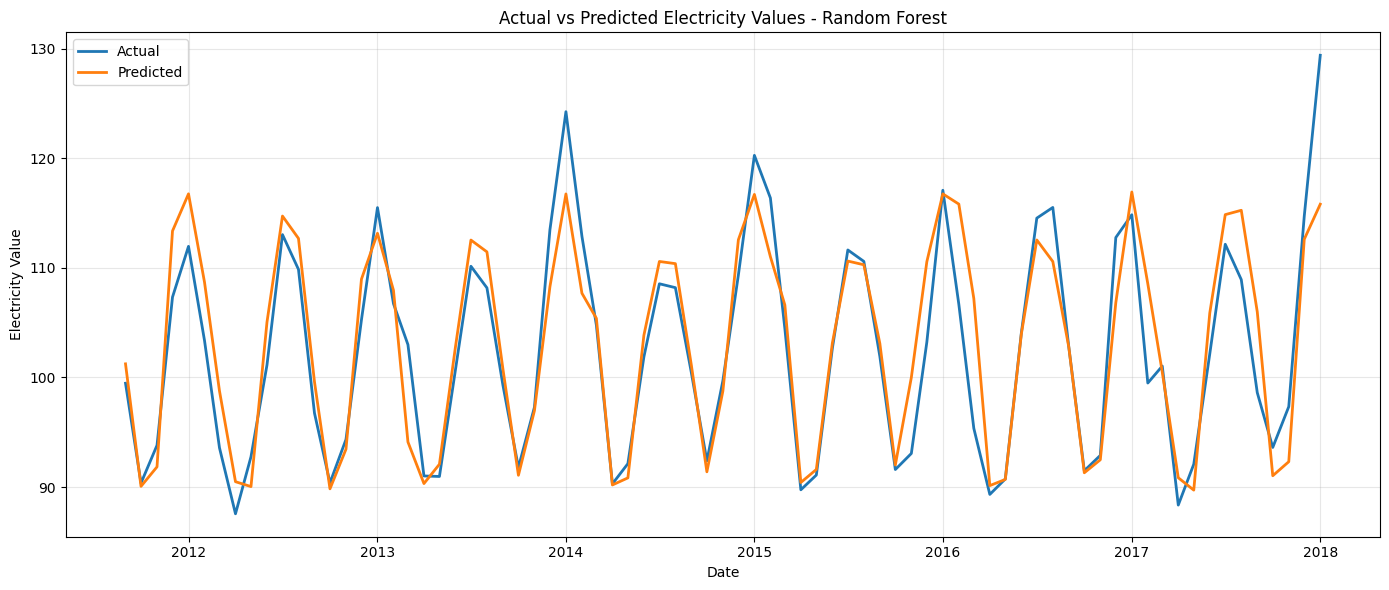

In [19]:
# Compare actual and predicted electricity values

plt.figure(figsize=(14, 6))

plt.plot(
    dates_test,
    y_test.values,
    label="Actual",
    linewidth=2
)

plt.plot(
    dates_test,
    best_predictions,
    label="Predicted",
    linewidth=2
)

plt.title(
    f"Actual vs Predicted Electricity Values - {best_model_name}"
)

plt.xlabel("Date")
plt.ylabel("Electricity Value")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

,Feature,Importance
6,Lag_12,0.968849
5,Lag_6,0.006984
2,Lag_1,0.006830
3,Lag_2,0.003292
7,Rolling_Mean_3,0.002888
4,Lag_3,0.002550
9,Rolling_Mean_12,0.002230
0,Year,0.002225
8,Rolling_Mean_6,0.002194
1,Month,0.001957


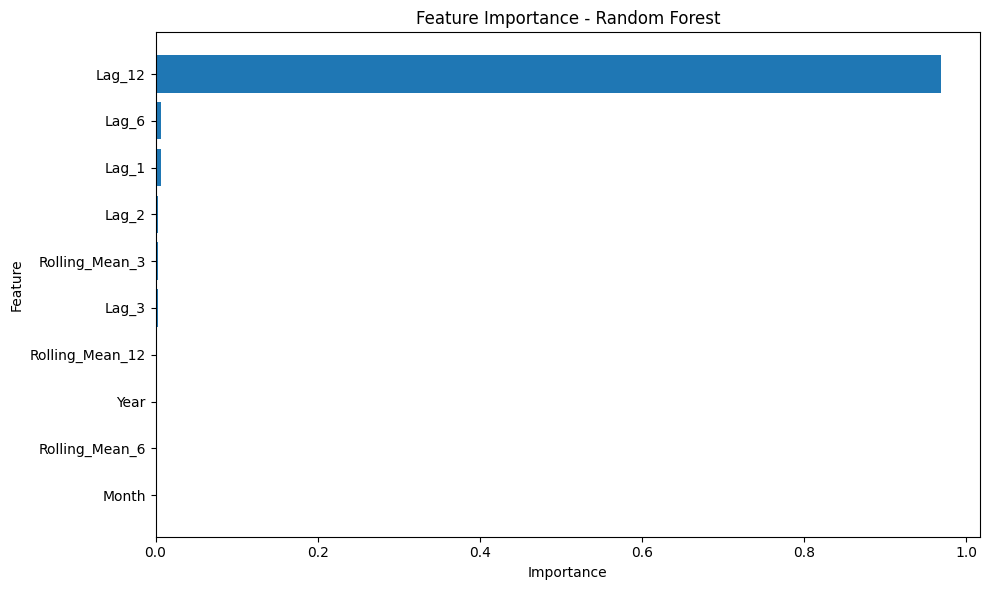

In [20]:
# Display which input features were most useful to the best model

if hasattr(best_model, "feature_importances_"):

    importance_df = pd.DataFrame({
        "Feature": feature_columns,
        "Importance": best_model.feature_importances_
    })

    importance_df = importance_df.sort_values(
        "Importance",
        ascending=False
    )

    display(importance_df)

    plt.figure(figsize=(10, 6))

    plt.barh(
        importance_df["Feature"],
        importance_df["Importance"]
    )

    plt.gca().invert_yaxis()

    plt.title(
        f"Feature Importance - {best_model_name}"
    )

    plt.xlabel("Importance")
    plt.ylabel("Feature")

    plt.tight_layout()
    plt.show()

In [21]:
# Forecast the next 12 months using the selected model

history = df[["DATE", "Value"]].copy()

future_predictions = []

for i in range(12):

    next_date = (
        history["DATE"].iloc[-1]
        + pd.DateOffset(months=1)
    )

    values = history["Value"].values

    features = {
        "Year": next_date.year,
        "Month": next_date.month,
        "Lag_1": values[-1],
        "Lag_2": values[-2],
        "Lag_3": values[-3],
        "Lag_6": values[-6],
        "Lag_12": values[-12],
        "Rolling_Mean_3": np.mean(values[-3:]),
        "Rolling_Mean_6": np.mean(values[-6:]),
        "Rolling_Mean_12": np.mean(values[-12:])
    }

    feature_row = pd.DataFrame(
        [features]
    )[feature_columns]

    prediction = best_model.predict(
        feature_row
    )[0]

    future_predictions.append({
        "DATE": next_date,
        "Predicted_Value": prediction
    })

    # Add the prediction to history so it can be
    # used for the following month's prediction.
    history = pd.concat(
        [
            history,
            pd.DataFrame({
                "DATE": [next_date],
                "Value": [prediction]
            })
        ],
        ignore_index=True
    )


future_df = pd.DataFrame(
    future_predictions
)

display(future_df)

,DATE,Predicted_Value
0,2018-02-01,102.617237
1,2018-03-01,101.280393
2,2018-04-01,90.553952
3,2018-05-01,91.657775
4,2018-06-01,104.304232
5,2018-07-01,113.297162
6,2018-08-01,110.145034
7,2018-09-01,99.809213
8,2018-10-01,92.853442
9,2018-11-01,98.859097


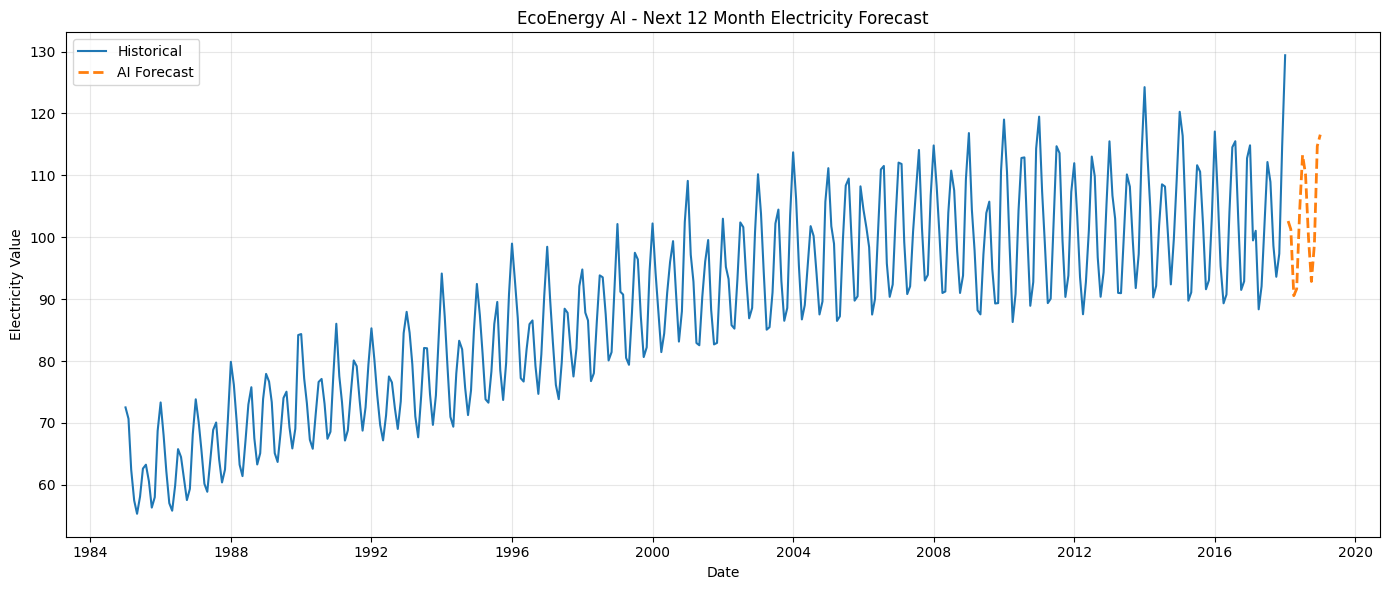

In [22]:
# Visualize the next 12 months forecast

plt.figure(figsize=(14, 6))

plt.plot(
    df["DATE"],
    df["Value"],
    label="Historical",
    linewidth=1.5
)

plt.plot(
    future_df["DATE"],
    future_df["Predicted_Value"],
    label="AI Forecast",
    linewidth=2,
    linestyle="--"
)

plt.title(
    f"EcoEnergy AI - Next 12 Month Electricity Forecast"
)

plt.xlabel("Date")
plt.ylabel("Electricity Value")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
# Calculate prediction errors on the test data

evaluation_df = pd.DataFrame({
    "DATE": dates_test.values,
    "Actual": y_test.values,
    "Predicted": best_predictions
})

evaluation_df["Error"] = (
    evaluation_df["Actual"]
    - evaluation_df["Predicted"]
)

evaluation_df["Absolute_Error"] = (
    evaluation_df["Error"].abs()
)

display(evaluation_df.head())

,DATE,Actual,Predicted,Error,Absolute_Error
0,2011-09-01,99.4712,101.241298,-1.770098,1.770098
1,2011-10-01,90.3566,90.061128,0.295472,0.295472
2,2011-11-01,93.8095,91.840628,1.968872,1.968872
3,2011-12-01,107.3312,113.365859,-6.034659,6.034659
4,2012-01-01,111.9646,116.756101,-4.791501,4.791501


In [24]:
# Detect unusually large prediction errors

train_predictions = best_model.predict(X_train)

train_errors = (
    y_train.values
    - train_predictions
)

error_std = np.std(train_errors)

# Threshold for identifying potential unusual observations
threshold = 2.5 * error_std

evaluation_df["Potential_Anomaly"] = (
    evaluation_df["Absolute_Error"] > threshold
)

anomalies = evaluation_df[
    evaluation_df["Potential_Anomaly"]
].copy()

print("Anomaly threshold:", round(threshold, 4))
print(
    "Potential anomalies detected:",
    len(anomalies)
)

display(anomalies)

Anomaly threshold: 3.7274
Potential anomalies detected: 21


,DATE,Actual,Predicted,Error,Absolute_Error,Potential_Anomaly
3,2011-12-01,107.3312,113.365859,-6.034659,6.034659,True
4,2012-01-01,111.9646,116.756101,-4.791501,4.791501,True
5,2012-02-01,103.3679,108.690374,-5.322474,5.322474,True
6,2012-03-01,93.5772,98.767594,-5.190394,5.190394,True
9,2012-06-01,101.1400,105.049628,-3.909628,3.909628,True
18,2013-03-01,102.9948,94.112508,8.882292,8.882292,True
27,2013-12-01,113.4732,108.279261,5.193939,5.193939,True
28,2014-01-01,124.2549,116.748224,7.506676,7.506676,True
29,2014-02-01,112.8811,107.684942,5.196158,5.196158,True
41,2015-02-01,116.3788,111.022048,5.356752,5.356752,True


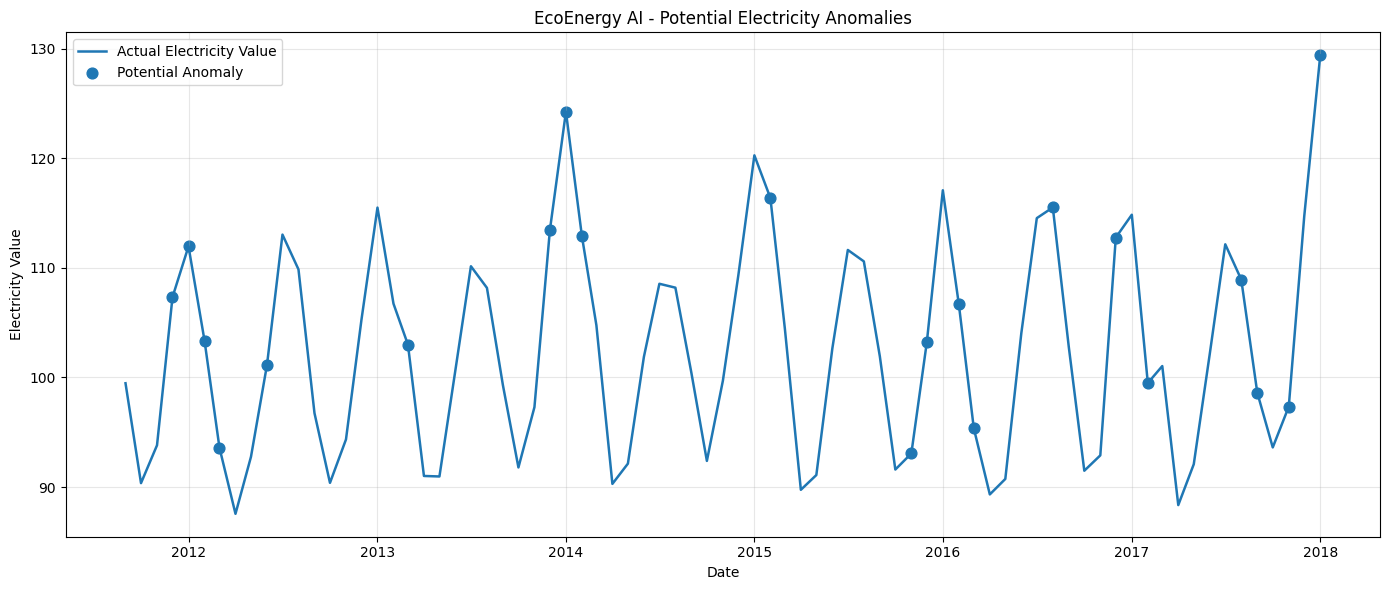

In [25]:
# Visualize potential anomalies

plt.figure(figsize=(14, 6))

plt.plot(
    evaluation_df["DATE"],
    evaluation_df["Actual"],
    label="Actual Electricity Value",
    linewidth=1.8
)

plt.scatter(
    anomalies["DATE"],
    anomalies["Actual"],
    label="Potential Anomaly",
    s=60
)

plt.title(
    "EcoEnergy AI - Potential Electricity Anomalies"
)

plt.xlabel("Date")
plt.ylabel("Electricity Value")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [26]:
# Generate simple sustainability-oriented recommendations

historical_average = df["Value"].mean()
forecast_average = future_df["Predicted_Value"].mean()

historical_high = df["Value"].quantile(0.75)
forecast_high = future_df["Predicted_Value"].max()

print("EcoEnergy AI Sustainability Insights")
print("=" * 55)

print(
    f"Historical average electricity value: "
    f"{historical_average:.2f}"
)

print(
    f"Forecast average electricity value: "
    f"{forecast_average:.2f}"
)

print(
    f"Highest forecasted value: "
    f"{forecast_high:.2f}"
)

print("\nRecommendations:")
print("-" * 55)

if forecast_average > historical_average:

    print(
        "1. Forecasted electricity demand is above the "
        "historical average. Energy-intensive operations "
        "should be reviewed during higher-demand periods."
    )

else:

    print(
        "1. Forecasted electricity demand is not above the "
        "historical average. Continued monitoring is recommended."
    )


if forecast_high > historical_high:

    print(
        "2. Some future periods may have relatively high "
        "electricity demand. HVAC, lighting and other "
        "energy-intensive systems can be reviewed."
    )


if len(anomalies) > 0:

    print(
        "3. Potential unusual electricity patterns were "
        "detected and should be investigated to determine "
        "their operational cause."
    )

else:

    print(
        "3. No potential anomalies were detected in the "
        "test period using the selected threshold."
    )


print("\nNote:")
print(
    "These recommendations are AI-assisted decision-support "
    "suggestions. They do not automatically control campus equipment."
)

EcoEnergy AI Sustainability Insights
Historical average electricity value: 88.85
Forecast average electricity value: 103.06
Highest forecasted value: 116.57

Recommendations:
-------------------------------------------------------
1. Forecasted electricity demand is above the historical average. Energy-intensive operations should be reviewed during higher-demand periods.
2. Some future periods may have relatively high electricity demand. HVAC, lighting and other energy-intensive systems can be reviewed.
3. Potential unusual electricity patterns were detected and should be investigated to determine their operational cause.

Note:
These recommendations are AI-assisted decision-support suggestions. They do not automatically control campus equipment.
